In [1]:
! pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for matplotlib!=3.6.1,>=3.4 from https://files.pythonhosted.org/packages/e5/2f/a58a4443a4d052a4ea77557478336aefc26c7981f6408d37adba763aa758/matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata
  Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Sakhiur\AppData\Local\Temp\ipykernel_14972\1424253957.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


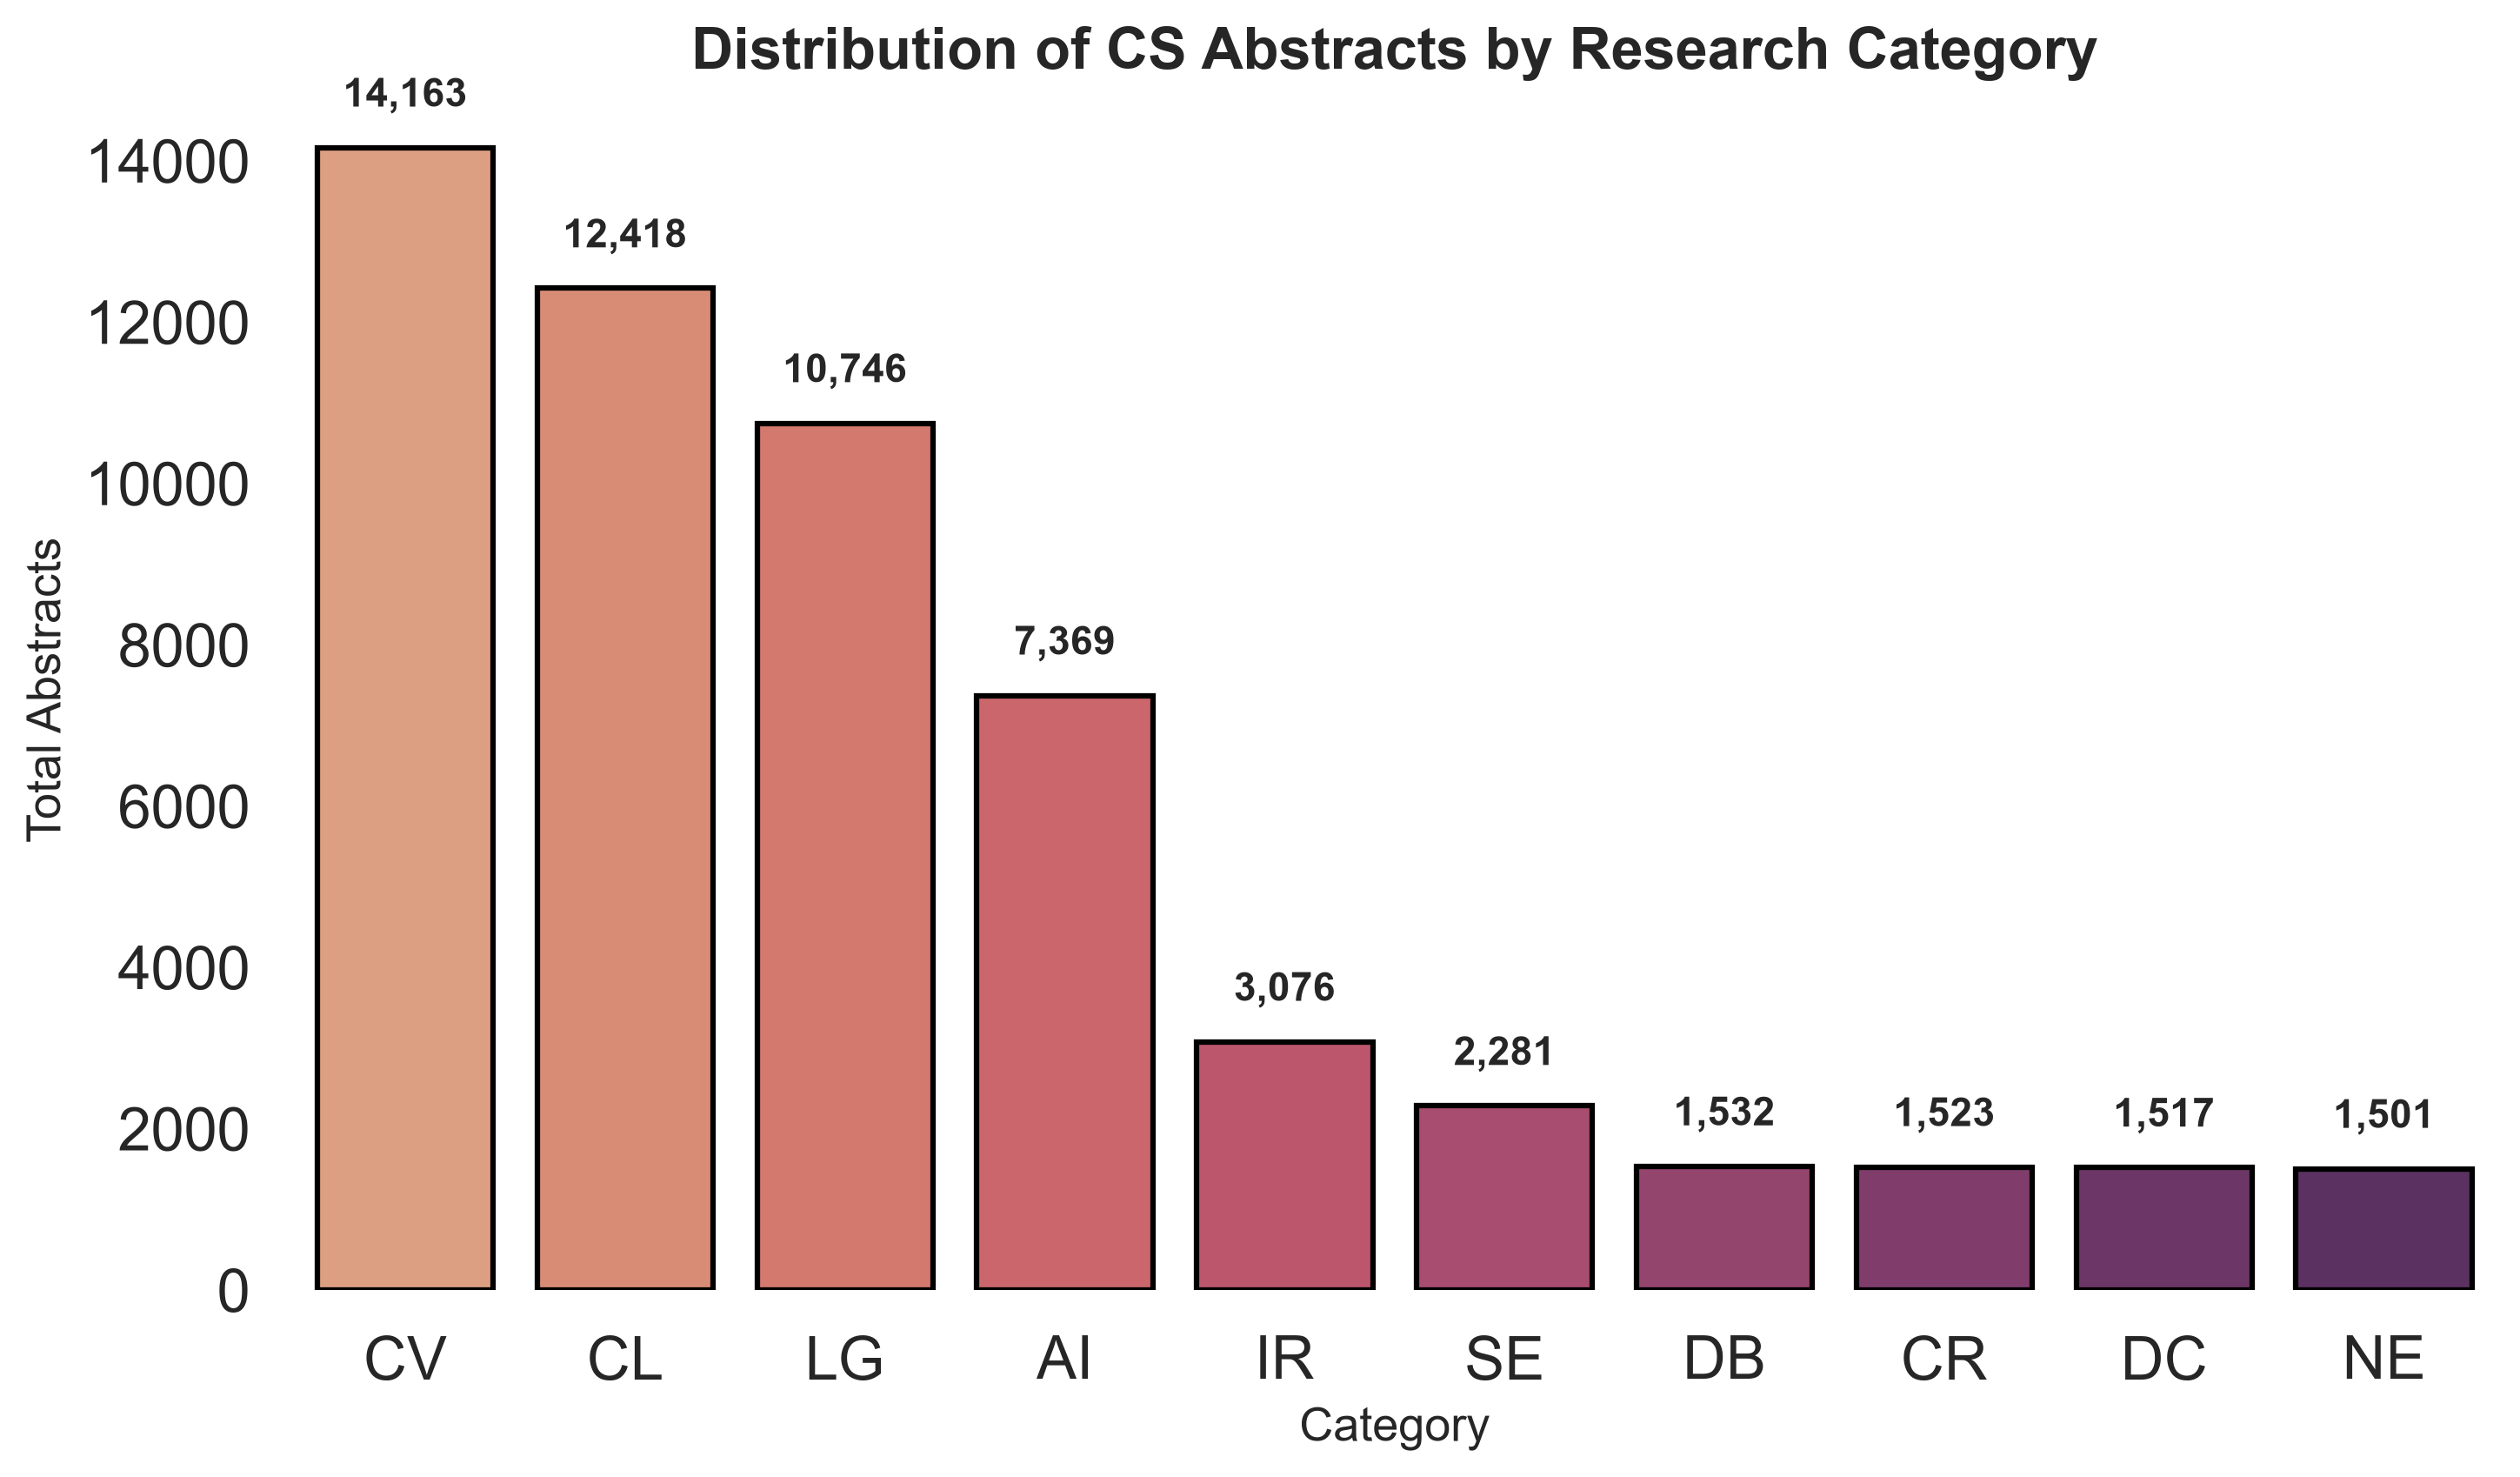

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data_sakhiur = {
    "Category": ["AI", "LG", "DB", "IR", "SE"],
    "Total Abstracts": [7369, 10746, 1532, 3076, 2281]
}
data_sadman ={
    "Category": ["CL", "CR", "CV", "DC", "NE"],
    "Total Abstracts": [12418, 1523, 14163, 1517, 1501]
}
data_combined = {
    "Category": data_sakhiur["Category"] + data_sadman["Category"],
    "Total Abstracts": data_sakhiur["Total Abstracts"] + data_sadman["Total Abstracts"]
}
df = pd.DataFrame(data_combined)


df = df.sort_values("Total Abstracts", ascending=False)

sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6), dpi=300)

palette = sns.color_palette("flare", len(df))

ax = sns.barplot(
    data=df,
    x="Category",
    y="Total Abstracts",
    palette=palette,
    linewidth=1.5,
    edgecolor='black'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 9),
        textcoords='offset points'
    )

ax.set_title("Distribution of CS Abstracts by Research Category", fontsize=16, weight='bold')
ax.set_xlabel("Category", fontsize=13)
ax.set_ylabel("Total Abstracts", fontsize=13)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save for paper / report
# plt.savefig("cs_abstract_distribution_sakhiur.png", dpi=300, bbox_inches="tight")
# plt.savefig("cs_abstract_distribution_sadman.png", dpi=300, bbox_inches="tight")
plt.savefig("../results/figures/cs_abstract_distribution_combined.png", dpi=300, bbox_inches="tight")

plt.show()

C:\Users\Sakhiur\AppData\Local\Temp\ipykernel_14972\1792661481.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


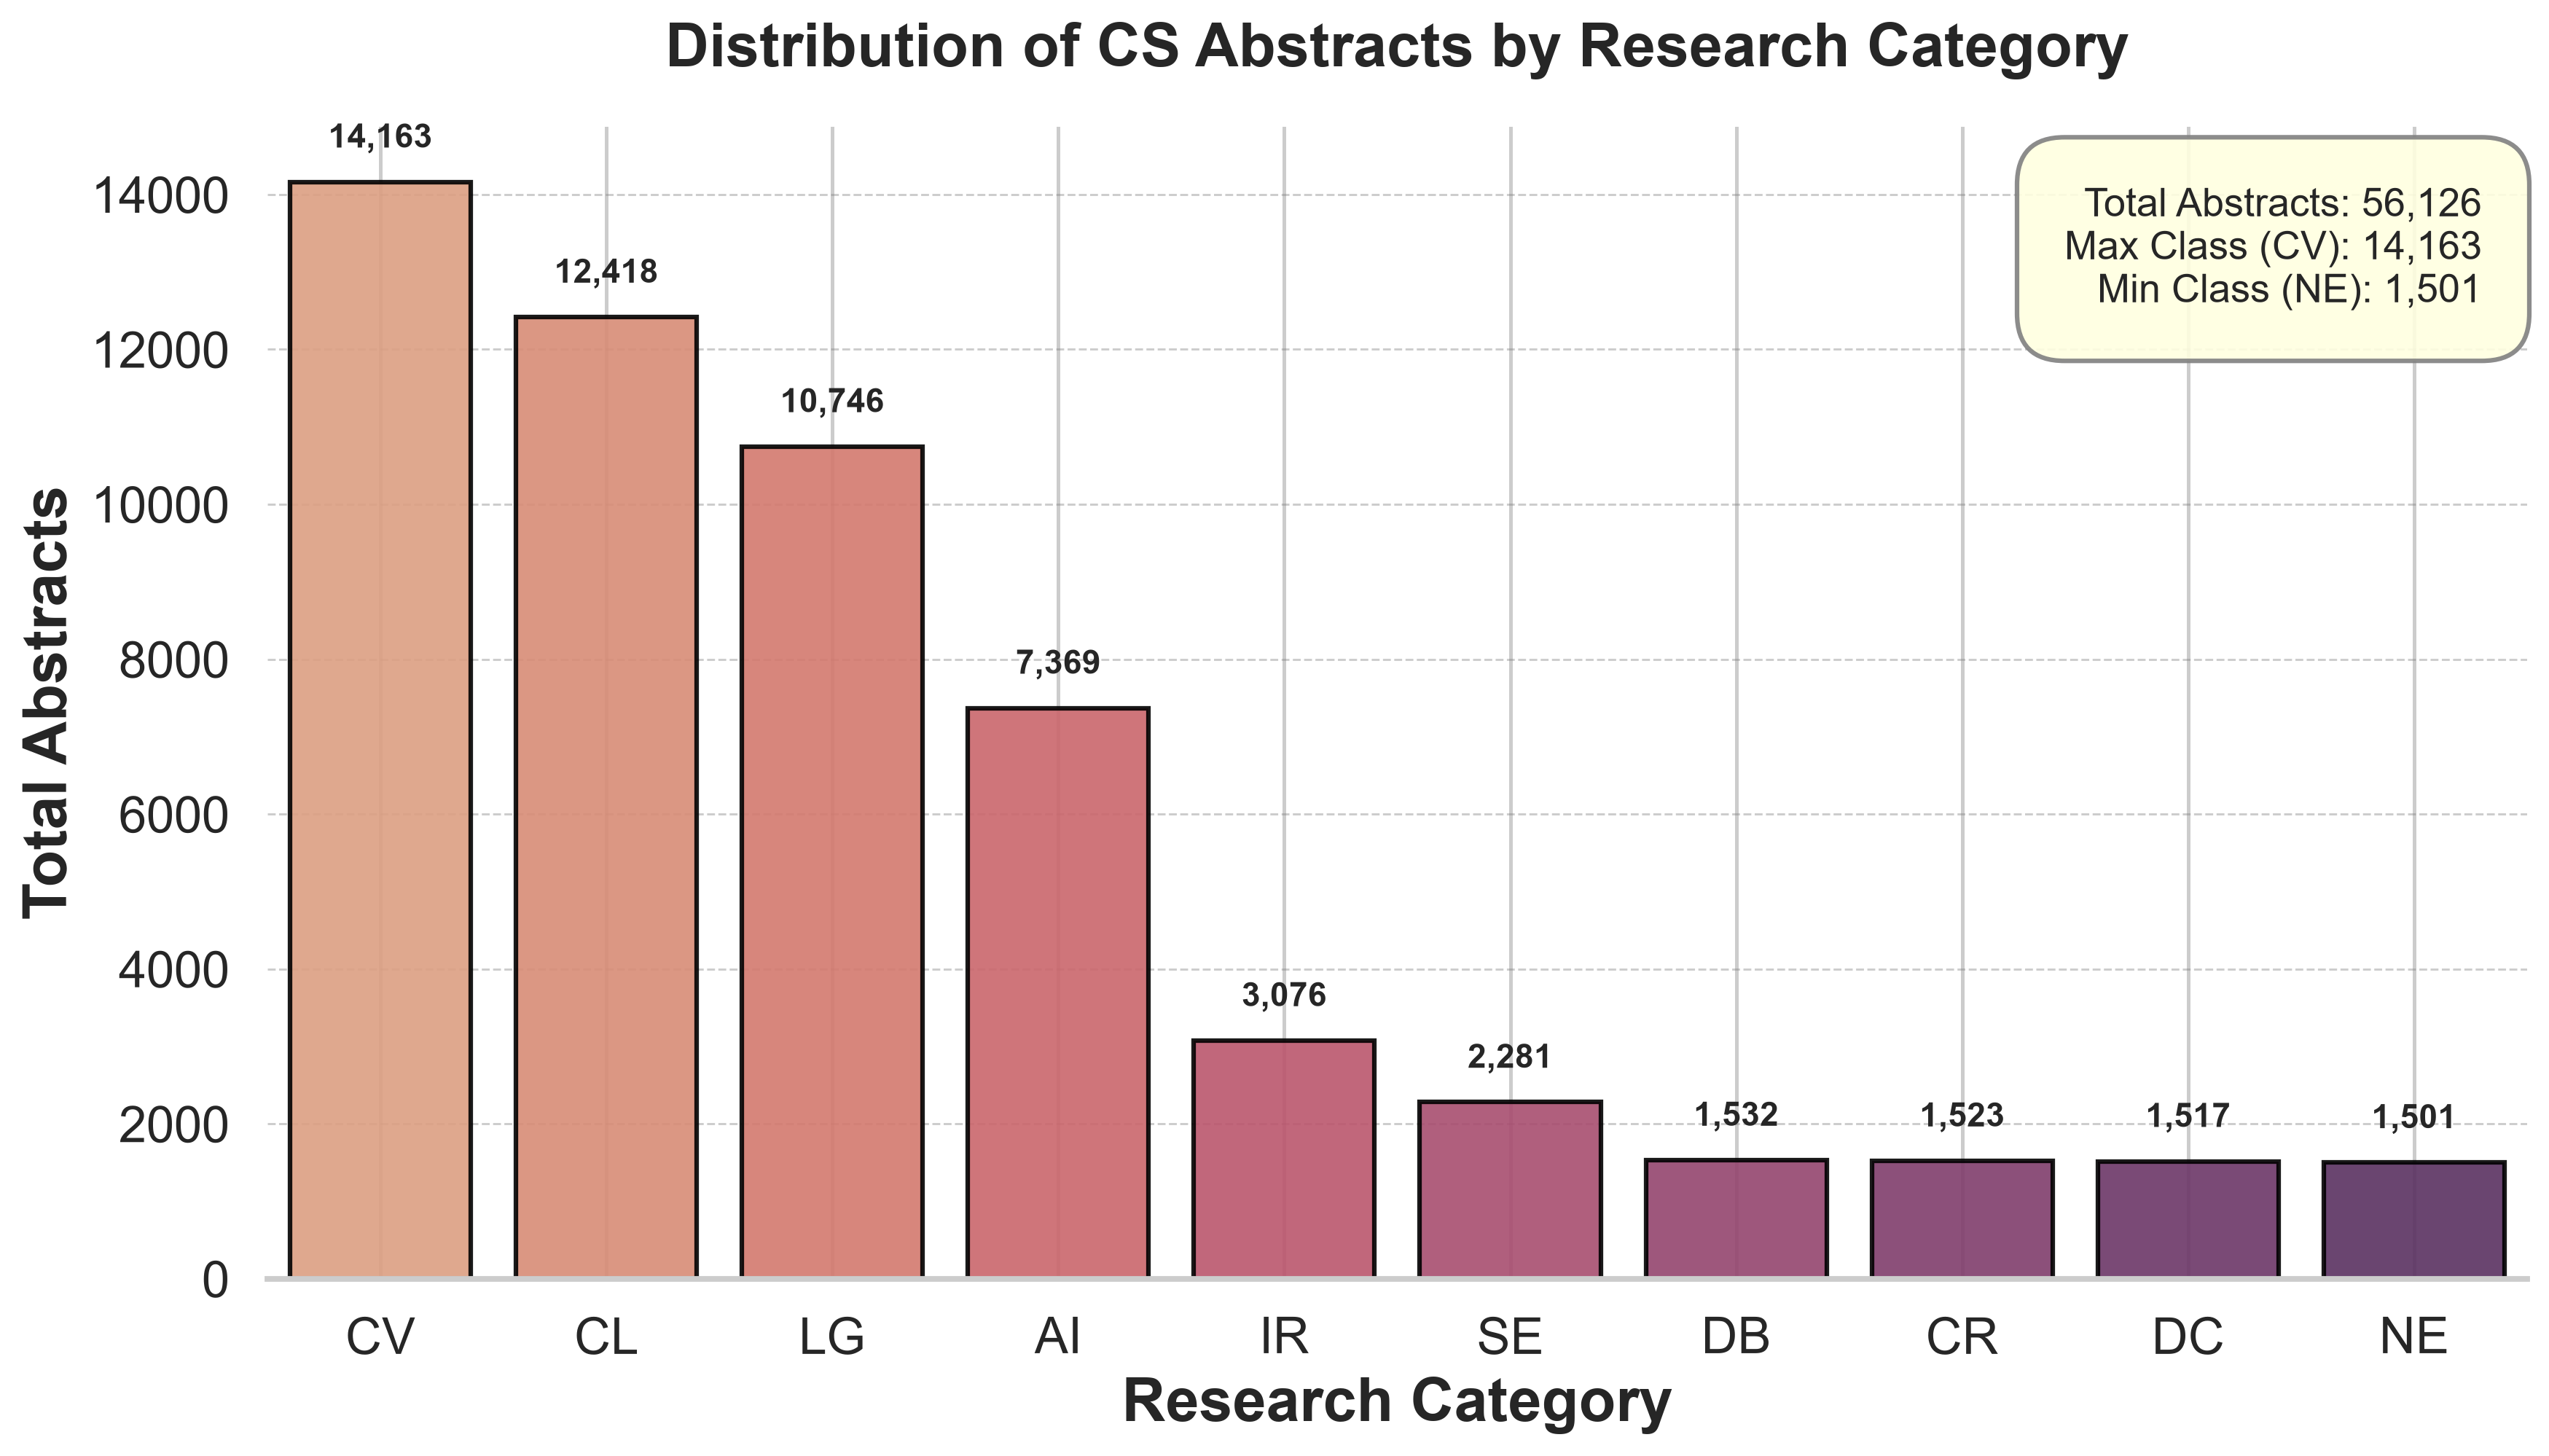

In [44]:
# 1. Data preparation
data_sakhiur = {
    "Category": ["AI", "LG", "DB", "IR", "SE"],
    "Total Abstracts": [7369, 10746, 1532, 3076, 2281]
}
data_sadman = {
    "Category": ["CL", "CR", "CV", "DC", "NE"],
    "Total Abstracts": [12418, 1523, 14163, 1517, 1501]
}
data_combined = {
    "Category": data_sakhiur["Category"] + data_sadman["Category"],
    "Total Abstracts": data_sakhiur["Total Abstracts"] + data_sadman["Total Abstracts"]
}
df = pd.DataFrame(data_combined)

# Sort values descending for a clean gradient look with the flare palette
df = df.sort_values("Total Abstracts", ascending=False).reset_index(drop=True)

# 2. Calculate statistics
total_samples = df["Total Abstracts"].sum()
max_count = df["Total Abstracts"].max()
min_count = df["Total Abstracts"].min()
max_cat = df.loc[df["Total Abstracts"].idxmax(), "Category"]
min_cat = df.loc[df["Total Abstracts"].idxmin(), "Category"]

# 3. Plotting
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Use flare palette (no custom colors)
palette = sns.color_palette("flare", len(df))

ax = sns.barplot(
    data=df,
    x="Category",
    y="Total Abstracts",
    palette=palette,
    linewidth=1.5,
    edgecolor='black',
    ax=ax,
    alpha=0.9
)
ax.grid(True, axis='x', linestyle='-', linewidth=1.2, color='gray', alpha=0.4)   # Vertical lines (stronger)
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, color='gray', alpha=0.4)

# 4. Annotate each bar with its count
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 9),
        textcoords='offset points'
    )

# 5. Title and labels
ax.set_title("Distribution of CS Abstracts by Research Category", fontsize=20, weight='bold', pad=20)
ax.set_xlabel("Research Category", fontsize=20, fontweight='bold')
ax.set_ylabel("Total Abstracts", fontsize=20, fontweight='bold')

# 6. Annotation box with key statistics (top right)
stats_text = (f'Total Abstracts: {total_samples:,}\n'
              f'Max Class ({max_cat}): {max_count:,}\n'
              f'Min Class ({min_cat}): {min_count:,}')
props = dict(boxstyle='round,pad=1.2', facecolor='lightyellow', alpha=0.9, edgecolor='gray')
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# 7. Annotate max and min classes with arrows
max_x = df["Category"].tolist().index(max_cat)
min_x = df["Category"].tolist().index(min_cat)

# # Arrow for Max Class
# ax.annotate('Max Class', xy=(max_x, max_count), xytext=(max_x + 0.75, max_count + 1200),
#             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#             fontsize=11, color='black', fontweight='bold')

# # Arrow for Min Class
# ax.annotate('Min Class', xy=(min_x, min_count), xytext=(min_x - 2, min_count + 2500),
#             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#             fontsize=11, color='black', fontweight='bold')

# 8. Adjust layout and save
sns.despine(left=True, bottom=False) # Kept bottom axis for category readability
plt.tight_layout()

# === Add border to entire plot ===
# for spine in ax.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(0.5)
#     spine.set_color('black')
#     spine.set_alpha(0.4)

# Save for paper / report
plt.savefig("../results/figures/cs_abstract_distribution_combined.png", dpi=300, bbox_inches="tight")
plt.show()